# Hotazel Steam – Forecasting Model Comparison
**Model 1:** revenue predicted using **production**
**Model 2:** revenue predicted using **coolDD**




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# to get rid of scientific notation
pd.options.display.float_format = '{:.2f}'.format



In [ ]:
HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')
display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


## Section 2 - Exploring the Data
Before building any model, we look at the data. We convert the date column into an actual date type, plot revenue over time to see the pattern, and check the correlations between revenue and our two candidate features (production and coolDD). Correlation tells us how strongly each feature moves with revenue (closer to 1 or -1 = stronger relationship).

In [ ]:
# make sure date is actually a date type
HS_data['date'] = pd.to_datetime(HS_data['date'])
HS_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   type        48 non-null     object        
 1   date        48 non-null     datetime64[ns]
 2   revenue     48 non-null     int64         
 3   production  48 non-null     int64         
 4   coolDD      48 non-null     int64         
 5   heatDD      48 non-null     int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 2.4+ KB


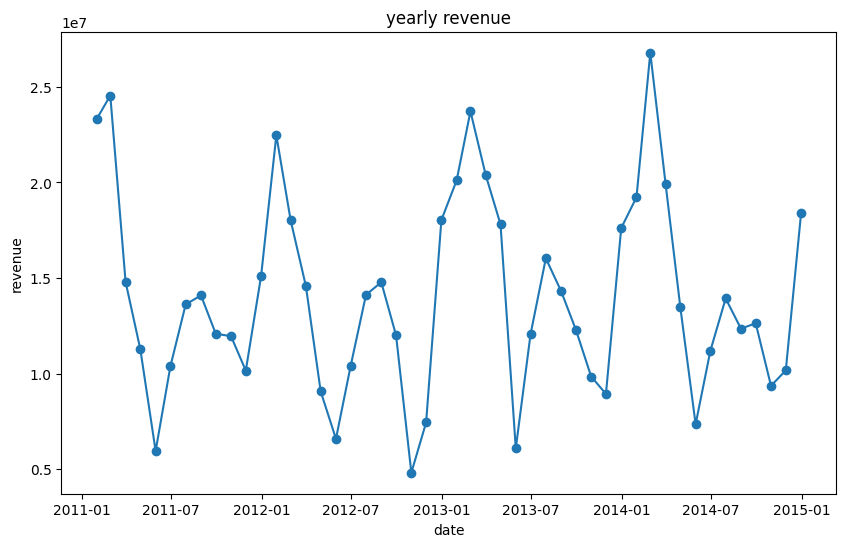

In [ ]:
# visualize the revenue we want to predict
plt.figure(figsize=(10,6))
plt.title('yearly revenue')
plt.xlabel('date')
plt.ylabel('revenue')
plt.plot(HS_data['date'], HS_data['revenue'], marker='o')

In [ ]:
# quantitative relationships between revenue and our candidate features
HS_data.loc[:, ['revenue','production','coolDD']].corr()

,revenue,production,coolDD
revenue,1.00,0.63,-0.17
production,0.63,1.00,0.51
coolDD,-0.17,0.51,1.00


## Section 3 - Separating Training and Testing Data
We split the data into two sets using the type column:
- **Training data** (dt4training) - used to teach (fit) the models
- **Testing data** (dt4testing)- held back so we can check how well the models predict data they have never seen

This prevents us from grading the models on the same data they memorized.

In [ ]:
dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

display(dt4training)
display(dt4testing)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


,type,date,revenue,production,coolDD,heatDD
36,dt4testing,2014-01-31,19228840,606400,0,1123
37,dt4testing,2014-02-28,26792280,714128,0,938
38,dt4testing,2014-03-31,19935840,805600,0,866
39,dt4testing,2014-04-30,13468000,375856,0,412
40,dt4testing,2014-05-31,7344128,279296,49,88
41,dt4testing,2014-06-30,11196216,517600,230,0
42,dt4testing,2014-07-31,13929472,749472,380,0
43,dt4testing,2014-08-31,12352176,663432,322,0
44,dt4testing,2014-09-30,12628944,701656,178,14
45,dt4testing,2014-10-31,9361000,411728,24,166


## Section 4 - Preparing and Training Model 1 (revenue ~ production)
A simple regression line is **y = mx + b**, where:
- **y** = dependent variable (revenue – what we want to predict)
- **x** = independent variable (production – the feature)
- **b** = intercept (revenue when production is 0)

We prepare y and x from the training data, add a constant for the intercept, then fit the model with sm.OLS(y, x).fit(). The summary shows the model's coefficients and fit statistics.

In [ ]:
import statsmodels.api as sm

# dependent variable = revenue
y = dt4training.loc[:,'revenue']

# independent variable = production, plus a constant for the intercept
x1 = dt4training.loc[:,'production']
x1 = sm.add_constant(x1)

# train the model
model1 = sm.OLS(y, x1).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     22.35
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           3.86e-05
Time:                        18:07:03   Log-Likelihood:                -598.32
No. Observations:                  36   AIC:                             1201.
Df Residuals:                      34   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.898e+06   2.01e+06      2.431      0.020    8.03e+05    8.99e+06
production    18.9920      4.017      4.728      0.000      10.828      27.156
==============================================================================
Omnibus:                        5.412   Durbin-Watson:                   0.444
Prob(Omnibus):                  0.067   Jarque-Bera (JB):                2.625
Skew:                           0.392   Prob(JB):                        0.269
Kurtosis:                       1.934   Cond. No.                     1.47e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.47e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# the coefficients give us our line: revenue = m * production + b
model1.params

,0
const,4897663.26
production,18.99


## Section 5 – Preparing and Training Model 2 (revenue ~ coolDD)
Exact same process as Model 1, but this time the independent variable is **coolDD** (cooling degree days) instead of production. The dependent variable is still revenue.

In [ ]:
# dependent variable is still revenue (y from above)

# independent variable = coolDD, plus a constant
x2 = dt4training.loc[:,'coolDD']
x2 = sm.add_constant(x2)

# train the model
model2 = sm.OLS(y, x2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.5883
Date:                Fri, 10 Jul 2026   Prob (F-statistic):              0.448
Time:                        18:07:03   Log-Likelihood:                -607.10
No. Observations:                  36   AIC:                             1218.
Df Residuals:                      34   BIC:                             1221.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.434e+07   1.08e+06     13.275      0.000    1.21e+07    1.65e+07
coolDD     -4113.9355   5363.430     -0.767      0.448    -1.5e+04    6785.866
==============================================================================
Omnibus:                        0.850   Durbin-Watson:                   0.964
Prob(Omnibus):                  0.654   Jarque-Bera (JB):                0.822
Skew:                           0.142   Prob(JB):                        0.663
Kurtosis:                       2.317   Cond. No.                         249.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# the coefficients give us our line: revenue = m * coolDD + b
model2.params

,0
const,14341632.04
coolDD,-4113.94


## Section 6 – Testing Model 1 and Calculating its MAPE
To test the model, we only give it the independent variable from the *testing* data (never the actual revenue), and ask it to predict revenue with .predict().

Then we calculate **MAPE (Mean Absolute Percentage Error)** – our universal measure of model performance:
1. Copy the testing data into an assessment dataframe (so we don't mess up the original)
2. Add the model's predicted revenues
3. Calculate the absolute percentage error for each row: |actual − predicted| / actual
4. Take the mean of those errors

A lower MAPE = a better model.

In [ ]:
# prepare the testing side: production only, plus constant
x1_test = dt4testing.loc[:,'production']
x1_test = sm.add_constant(x1_test)

# assessment dataframe for model 1
model1_assessment = dt4testing.copy()
model1_assessment['model1_predicted_revenue'] = model1.predict(x1_test)

model1_assessment['model1_pctError'] = abs((
    model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue']) / model1_assessment['revenue']
)

display(model1_assessment)

,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,model1_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,16414428.69,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,18460401.82,0.31
38,dt4testing,2014-03-31,19935840,805600,0,866,20197640.55,0.01
39,dt4testing,2014-04-30,13468000,375856,0,412,12035930.72,0.11
40,dt4testing,2014-05-31,7344128,279296,49,88,10202060.55,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,14727936.65,0.32
42,dt4testing,2014-07-31,13929472,749472,380,0,19131656.04,0.37
43,dt4testing,2014-08-31,12352176,663432,322,0,17497582.00,0.42
44,dt4testing,2014-09-30,12628944,701656,178,14,18223533.25,0.44
45,dt4testing,2014-10-31,9361000,411728,24,166,12717212.73,0.36


In [ ]:
model1_MAPE = model1_assessment['model1_pctError'].mean()
print('Model 1 (production) MAPE:', model1_MAPE)

Model 1 (production) MAPE: 0.2542315606071484


## Section 7 – Testing Model 2 and Calculating its MAPE
Same testing process for Model 2: feed it only the coolDD values from the testing data, get predicted revenues, then calculate the absolute percentage error for each row and take the mean.

In [ ]:
# prepare the testing side: coolDD only, plus constant
x2_test = dt4testing.loc[:,'coolDD']
x2_test = sm.add_constant(x2_test)

# assessment dataframe for model 2
model2_assessment = dt4testing.copy()
model2_assessment['model2_predicted_revenue'] = model2.predict(x2_test)

model2_assessment['model2_pctError'] = abs((
    model2_assessment['revenue'] - model2_assessment['model2_predicted_revenue']) / model2_assessment['revenue']
)

display(model2_assessment)

,type,date,revenue,production,coolDD,heatDD,model2_predicted_revenue,model2_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,14341632.04,0.25
37,dt4testing,2014-02-28,26792280,714128,0,938,14341632.04,0.46
38,dt4testing,2014-03-31,19935840,805600,0,866,14341632.04,0.28
39,dt4testing,2014-04-30,13468000,375856,0,412,14341632.04,0.06
40,dt4testing,2014-05-31,7344128,279296,49,88,14140049.20,0.93
41,dt4testing,2014-06-30,11196216,517600,230,0,13395426.88,0.20
42,dt4testing,2014-07-31,13929472,749472,380,0,12778336.56,0.08
43,dt4testing,2014-08-31,12352176,663432,322,0,13016944.82,0.05
44,dt4testing,2014-09-30,12628944,701656,178,14,13609351.53,0.08
45,dt4testing,2014-10-31,9361000,411728,24,166,14242897.59,0.52


In [ ]:
model2_MAPE = model2_assessment['model2_pctError'].mean()
print('Model 2 (coolDD) MAPE:', model2_MAPE)

Model 2 (coolDD) MAPE: 0.2960295810593141


## Section 8 – Visualization: Both Models vs. Actual Testing Data
Percentages are hard for people to conceptualize, so we always visualize. This chart plots the actual revenue from the testing data (green) against Model 1's predictions (red) and Model 2's predictions (blue). The line that hugs the green line most closely is the better model.

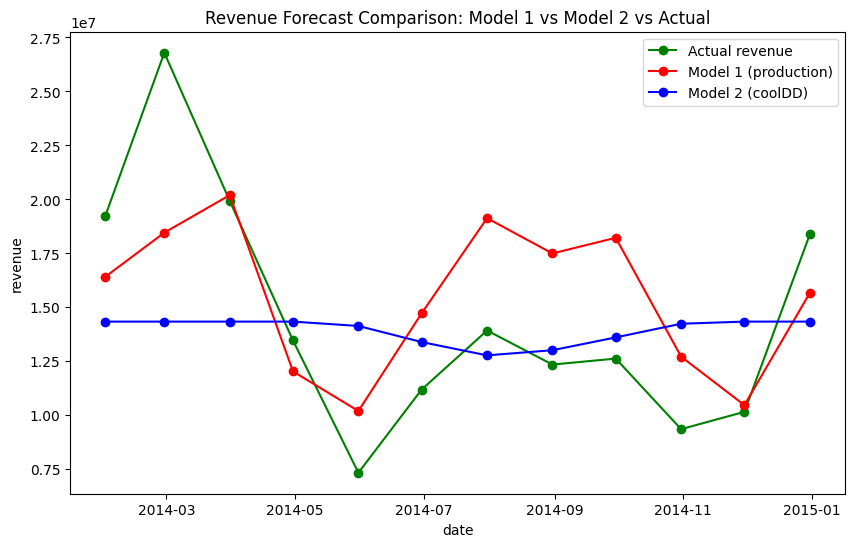

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Revenue Forecast Comparison: Model 1 vs Model 2 vs Actual')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'], model1_assessment['revenue'], marker='o', color='green', label='Actual revenue')
plt.plot(model1_assessment['date'], model1_assessment['model1_predicted_revenue'], marker='o', color='red', label='Model 1 (production)')
plt.plot(model2_assessment['date'], model2_assessment['model2_predicted_revenue'], marker='o', color='blue', label='Model 2 (coolDD)')

plt.legend()
plt.show()

## Section 9 – Memo of Key Findings

To: Hotazel Steam Management

From: Rayah Suleman

Re: Comparison of Two Revenue Forecasting Models

We built and tested two simple regression models to forecast revenue. Model 1 predicts revenue using production, and Model 2 predicts revenue using cooling degree days (coolDD). Both models were trained on the same historical training data and evaluated on testing data the models had never seen, using MAPE (Mean Absolute Percentage Error) as the performance measure.

Results:
Model 1 (production) MAPE: 25.4%
Model 2 (coolDD) MAPE: 29.6%

Key finding: Model 1 produced the lower MAPE, meaning its forecasts were, on average, closer to actual revenue. This is consistent with the correlation analysis in Section 2, where production showed the stronger correlation with revenue (0.63, versus −0.17 for coolDD), and with the comparison chart in Section 8, where Model 1's predictions track the actual revenue line more closely.

Recommendation: We recommend Hotazel Steam use Model 1 (production) for revenue forecasting going forward, as it delivers more accurate predictions on unseen data. That said, both models have fairly high error rates (over 25%), so as a next step we could explore a multiple regression that combines both features (and heatDD), which may improve accuracy further.